## Import packages

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy import integrate
import sys
import os
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "ADFWI").exists():
    REPO_ROOT = Path("/liufeng1afs/project/04_Inversion/ADFWI-github")
os.chdir(REPO_ROOT)

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import ADFWI
from ADFWI.propagator  import *
from ADFWI.model       import *
from ADFWI.view        import *
from ADFWI.utils       import *
from ADFWI.survey      import *

project_path = os.path.join("examples", "validation", "marmousi2_acoustic_bv12", "outputs", "minimal_notebook")
for subdir in ["model", "waveform", "survey", "inversion"]:
    os.makedirs(os.path.join(project_path, subdir), exist_ok=True)
from ADFWI.fwi         import *


/liufeng1afs/software/miniconda3/envs/adfwi/lib/python3.9/site-packages/torch_npu/utils/collect_env.py:58: UserWarning: Warning: The /usr/local/Ascend/ascend-toolkit/latest owner does not match the current owner.
  warnings.warn(f"Warning: The {path} owner does not match the current owner.")
/liufeng1afs/software/miniconda3/envs/adfwi/lib/python3.9/site-packages/torch_npu/utils/collect_env.py:58: UserWarning: Warning: The /usr/local/Ascend/ascend-toolkit/8.2.RC2/aarch64-linux/ascend_toolkit_install.info owner does not match the current owner.
  warnings.warn(f"Warning: The {path} owner does not match the current owner.")
/liufeng1afs/software/miniconda3/envs/adfwi/lib/python3.9/site-packages/torch_npu/utils/collect_env.py:58: UserWarning: Warning: The /usr/local/Ascend/ascend-toolkit/latest owner does not match the current owner.
  warnings.warn(f"Warning: The {path} owner does not match the current owner.")
/liufeng1afs/software/miniconda3/envs/adfwi/lib/python3.9/site-packages/torch_

## Define the basic model parameter

In [2]:
device = "npu:0"          # Validation device
backend = ADFWI.set_backend(device, dtype="float32")
dtype = torch.float32     # Set data type to 32-bit floating point
ox, oz = 0, 0             # Origin coordinates for x and z directions
nz, nx = 88, 200          # Grid dimensions in z and x directions
dx, dz = 40, 40           # Grid spacing in x and z directions
nt, dt = 3000, 0.003      # Time steps and time interval
nabc = 30                 # Thickness of the absorbing boundary layer
f0 = 5                    # Initial frequency in Hz
free_surface = True       # Enable free surface boundary condition

validation_shots = 3      # Keep validation small; increase to 40 to match the full example
iteration = 10            # Use 100 for the longer validation pass
batch_size = validation_shots
checkpoint_segments = 1   # NPU memory is sufficient for the current reduced validation


## Define the initial velocity model

In [3]:
# Load the Marmousi model dataset from the specified directory.
marmousi_model = load_marmousi_model(in_dir="./examples/datasets/marmousi2_source")

# Create coordinate arrays for x and z based on the grid size.
x = np.linspace(5000, 5000 + dx * nx, nx)
z = np.linspace(0, dz * nz, nz)
true_model = resample_marmousi_model(x, z, marmousi_model)
smooth_model = get_smooth_marmousi_model(true_model, gaussian_kernel=6, rcv_depth=10, mask_extra_detph=2)

# Initialize primary wave velocity (vp) and density (rho) for the model.
vp_init = smooth_model["vp"].T
rho_init = np.power(vp_init, 0.25) * 310

# Extract true model properties for comparison.
vp_true = true_model["vp"].T
rho_true = np.power(vp_true, 0.25) * 310

model = AcousticModel(ox, oz, nx, nz, dx, dz,
                      vp_init, rho_init,
                      vp_bound=[vp_true.min(), vp_true.max()],
                      vp_grad=True,
                      free_surface=free_surface,
                      abc_type="PML", abc_jerjan_alpha=0.007,
                      nabc=nabc,
                      auto_update_rho=True,
                      device=device, dtype=dtype)

# Save the initialized model to a file for later use.
model.save(os.path.join(project_path, "model/init_model.npz"))

# Print the model's representation for verification.
print(model.__repr__())


model with parameters ['vp', 'rho']:
  Model vp  :  1500.00 -  4146.96 m/s   , requires_grad = True, constrain bound: 1499.9999999999998 - 4777.700048035684
  Model rho :  1929.23 -  2487.68 kg/m^3, requires_grad = False, constrain bound: None - None
  Model orig: ox =   0.00, oz =   0.00 m
  Model grid: dx =  40.00, dz =  40.00 m
  Model dims: nx =    200, nz =     88
  Model size: 35200
  Free surface: True
  Absorbing layers: 30



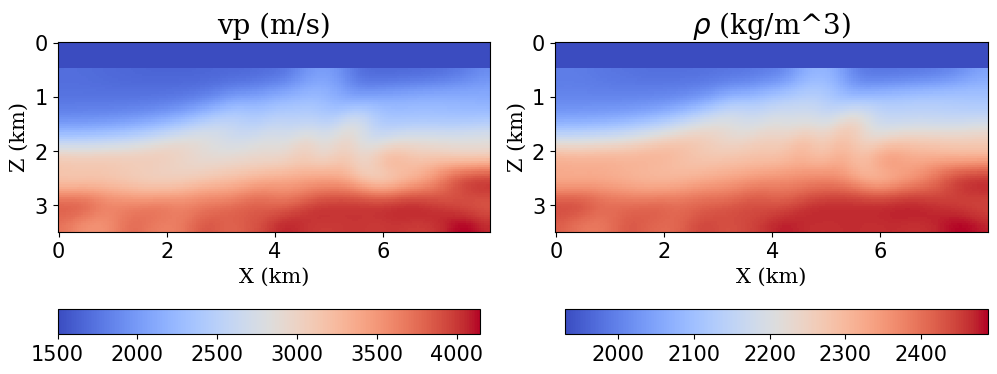

In [4]:
model._plot_vp_rho(figsize=(12, 5), wspace=0.15, cbar_pad_fraction=0.01,
                   cmap="coolwarm", save_path=os.path.join(project_path, "model/init_vp_rho.png"))


## Define the observed systems: Survey = Source + Receiver

In [5]:
# Define source positions in the model
src_z = np.array([1 for i in range(2, nx - 1, 5)])[:validation_shots]
src_x = np.array([i for i in range(2, nx - 1, 5)])[:validation_shots]

# Generate wavelet for the source
src_t, src_v = wavelet(nt, dt, f0, amp0=1)
try:
    src_v = integrate.cumtrapz(src_v, axis=-1, initial=0)
except AttributeError:
    src_v = integrate.cumulative_trapezoid(src_v, axis=-1, initial=0)

source = Source(nt=nt, dt=dt, f0=f0)

# Add each source position individually, matching the original Marmousi2 example style
for i in range(len(src_x)):
    source.add_source(src_x=src_x[i], src_z=src_z[i], src_wavelet=src_v,
                      src_type="mt", src_mt=np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]]))


In [6]:
# Define receiver positions in the model
rcv_z = np.array([1 for i in range(0, nx, 1)])
rcv_x = np.array([j for j in range(0, nx, 1)])

receiver = Receiver(nt=nt, dt=dt)

# Add each receiver individually, matching the original Marmousi2 example style
for i in range(len(rcv_x)):
    receiver.add_receiver(rcv_x=rcv_x[i], rcv_z=rcv_z[i], rcv_type="pr")


In [7]:
# Create a survey object using the defined source and receiver
survey = Survey(source=source, receiver=receiver)

# Print a representation of the survey object to check its configuration
print(survey.__repr__())


Survey Information:
Seismic Source:
  Source wavelet: 3000 samples at 3.00 ms
  Source number : 3
  Source types  : ['mt']
  Source x range: 2 - 12 (grids)
  Source z range: 1 - 1 (grids)

Seismic Receiver:
  Receiver data   : 3000 samples at 3.00 ms
  Receiver number : 200
  Receiver types  : ['pr']
  Receiver x range: 0 - 199 (grids)
  Receiver z range: 1 - 1 (grids)



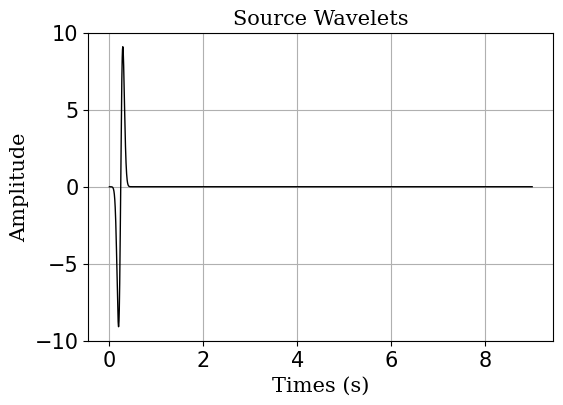

In [8]:
# Plot the wavelet used in the source
source.plot_wavelet(save_path=os.path.join(project_path, "survey/wavelets.png"))


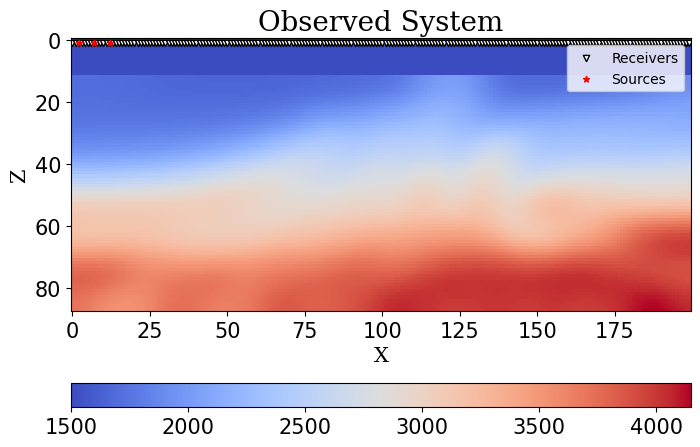

In [9]:
# Plot the survey configuration over the velocity model
survey.plot(model.vp, cmap="coolwarm", save_path=os.path.join(project_path, "survey/observed_system_init.png"))


## Define the propagator

In [10]:
# Initialize the wave propagator using the specified model and survey configuration
F = AcousticPropagator(model, survey, device=device)


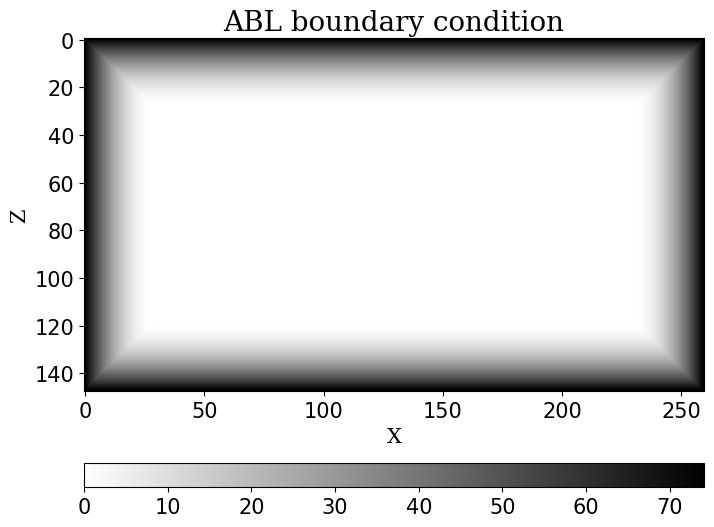

In [11]:
# Retrieve the damping array from the propagator and plot it to visualize boundary conditions
damp = F.damp
plot_damp(damp, save_path=os.path.join(project_path, "model/boundary_condition.png"))


## Load observed datasets

In [12]:
# Create an instance of SeismicData using the survey object.
d_obs = SeismicData(survey)

# Load observed waveform data generated by 01_forward_modeling.ipynb.
obs_path = os.path.join(project_path, "waveform/obs_data.npz")
if not os.path.exists(obs_path):
    raise FileNotFoundError("Run notebooks/01_forward_modeling.ipynb first to generate obs_data.npz")
d_obs.load(obs_path)

# Print a summary representation of the observed seismic data.
print(d_obs.__repr__())


Seismic Data:
  Source number : 3
  Receiver number : 200
  Time samples : 3000 samples at 3.00 ms



## Inversion

In [13]:
# Import the L2 misfit function for waveform inversion.
from ADFWI.fwi.misfit import Misfit_waveform_L2, Misfit_global_correlation

# Initialize the optimizer (Adam) for model parameters with a learning rate.
optimizer = torch.optim.Adam(model.parameters(), lr=10)

# Set up a learning rate scheduler to adjust the learning rate over time.
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=200, gamma=0.75, last_epoch=-1)

# Configure the misfit function to compute the loss based on the observed data.
loss_fn = Misfit_waveform_L2(dt=1)
# loss_fn = Misfit_global_correlation(dt=1)

# Gradient processor
grad_mask = np.ones_like(vp_init)
grad_mask[:12, :] = 0
gradient_processor = GradProcessor(grad_mask=grad_mask)

# Initialize the acoustic full waveform inversion (FWI) object.
fwi = AcousticFWI(propagator=F,
                  model=model,
                  optimizer=optimizer,
                  scheduler=scheduler,
                  loss_fn=loss_fn,
                  obs_data=d_obs,
                  gradient_processor=gradient_processor,
                  waveform_normalize=True,
                  cache_result=True,
                  save_fig_epoch=50,
                  save_fig_path=os.path.join(project_path, "inversion"))

# Run inversion for the validation iteration count.
fwi.forward(iteration=iteration, batch_size=batch_size, checkpoint_segments=checkpoint_segments)

# Retrieve the inversion results: updated velocity and loss values.
iter_vp = fwi.iter_vp
iter_rho = fwi.iter_rho
iter_loss = fwi.iter_loss

# Save the iteration results to files for later analysis.
np.savez(os.path.join(project_path, "inversion/iter_vp.npz"), data=np.array(iter_vp))
np.savez(os.path.join(project_path, "inversion/iter_loss.npz"), data=np.array(iter_loss))


## Visualize the inverted results

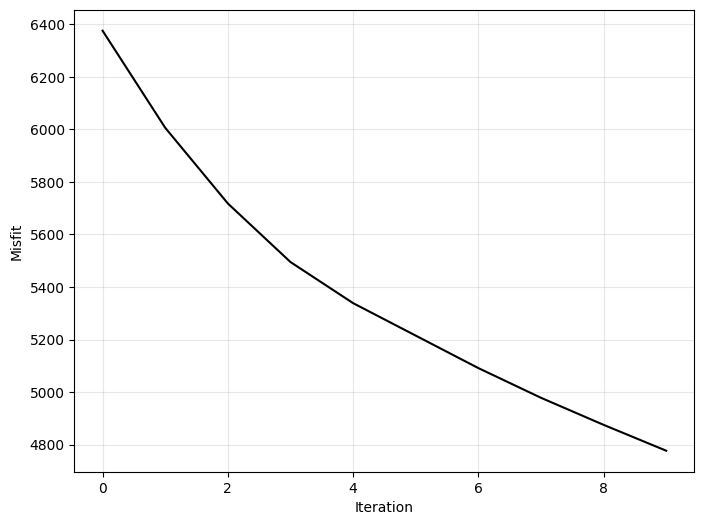

In [14]:
# Plot the misfit
plt.figure(figsize=(8, 6))
plt.plot(iter_loss, c="k")
plt.xlabel("Iteration")
plt.ylabel("Misfit")
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(project_path, "inversion/loss.png"), bbox_inches="tight")
plt.show()


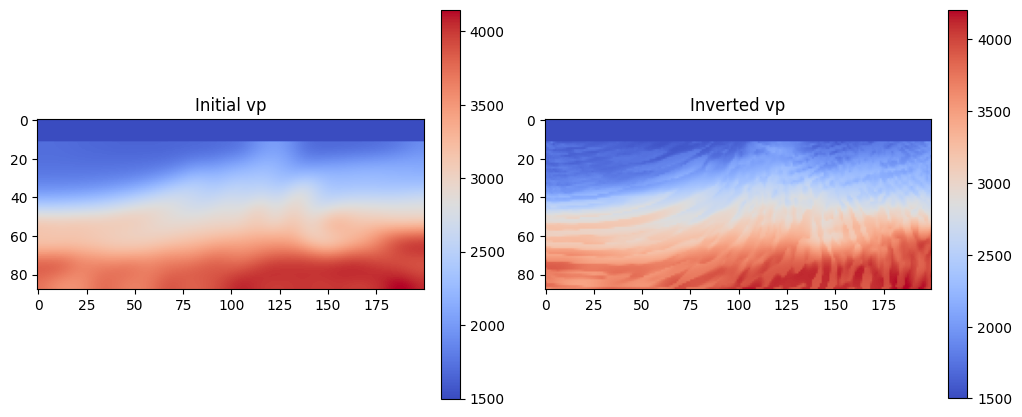

In [15]:
# Plot the initial model and inverted result
plt.figure(figsize=(12, 8))
plt.subplot(121)
plt.imshow(vp_init, cmap="coolwarm")
plt.title("Initial vp")
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(122)
plt.imshow(iter_vp[-1], cmap="coolwarm")
plt.title("Inverted vp")
plt.colorbar(fraction=0.046, pad=0.04)
plt.savefig(os.path.join(project_path, "inversion/init_vs_inverted_vp.png"), bbox_inches="tight")
plt.show()


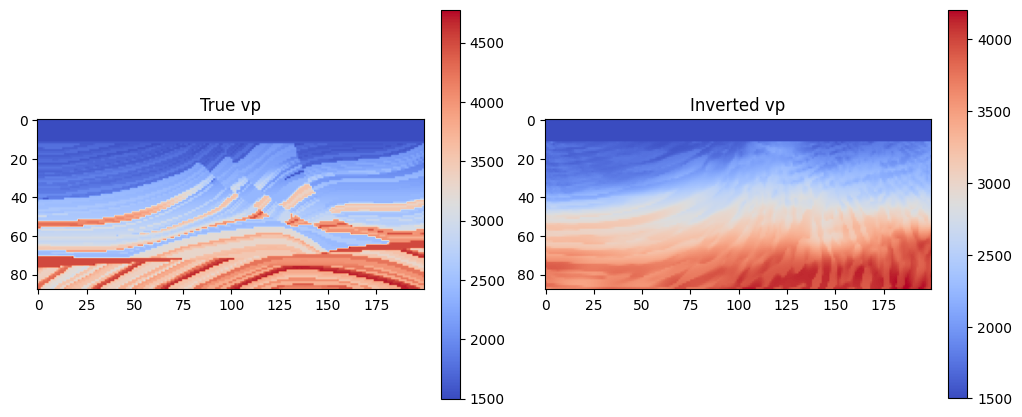

In [16]:
# Plot the true model and inverted result
plt.figure(figsize=(12, 8))
plt.subplot(121)
plt.imshow(vp_true, cmap="coolwarm")
plt.title("True vp")
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(122)
plt.imshow(iter_vp[-1], cmap="coolwarm")
plt.title("Inverted vp")
plt.colorbar(fraction=0.046, pad=0.04)
plt.savefig(os.path.join(project_path, "inversion/true_vs_inverted_vp.png"), bbox_inches="tight")
plt.show()
